# CC3092 – Deep Learning · Laboratorio 7
## Forecasting de temperatura de aceite (ETTh1) con LSTM y Transformer implementados desde cero
**Entrega parcial: Task 1 y Task 2**

**Entrega final: Todo**

## Task 1.1 – Descarga y preprocesamiento

In [1]:
import urllib.request
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT)
print("Longitud de la serie:", len(OT))

Dispositivo: cpu


Longitud de la serie: 17420


### a) y b) Normalización z-score y split temporal 60/20/20

Normalización: $z_t = \dfrac{x_t - \mu}{\sigma}$. Para desnormalizar: $x_t = z_t\,\sigma + \mu$.

$\mu$ y $\sigma$ se calculan solo con el bloque de entrenamiento, para no filtrar información del futuro (validación/prueba) al modelo. Luego se aplica la misma transformación a toda la serie.

In [2]:
N_total = len(OT)
n_train = int(0.6 * N_total)          # índice donde termina train
n_val   = int(0.8 * N_total)          # índice donde termina val

# mu y sigma calculados solo sobre el bloque de entrenamiento 
mu    = float(OT[:n_train].mean())
sigma = float(OT[:n_train].std())

# z_t = (x_t - mu) / sigma
OT_norm = torch.tensor((OT - mu) / sigma, dtype=torch.float32)

# Bloques contiguos, sin mezcla aleatoria: [0, n_train) | [n_train, n_val) | [n_val, N)
OT_train = OT_norm[:n_train]
OT_val   = OT_norm[n_train:n_val]
OT_test  = OT_norm[n_val:]

def denorm(z):
    """x_t = z_t * sigma + mu"""
    return z * sigma + mu

print(f"mu = {mu:.4f} °C, sigma = {sigma:.4f} °C")
print(f"train: {len(OT_train)}, val: {len(OT_val)}, test: {len(OT_test)}")

mu = 17.2925 °C, sigma = 8.5137 °C
train: 10452, val: 3484, test: 3484


### c) Ventanas deslizantes

Para cada instante $t$: $X^{(t)} = (x_{t-L+1},\dots,x_t)$ y $y^{(t)} = x_{t+H}$.

Si la serie tiene $T$ puntos, el primer $t$ válido es $t=L-1$ y el último es $t=T-1-H$, por lo que $N = T - L - H + 1$ ejemplos. Cada split se ventanea por separado, así ninguna ventana cruza la frontera entre conjuntos.

In [3]:
def make_windows(series, L, H):
    """
    series : tensor 1D (T,)
    Retorna X (N, L) y y (N,) con
        X[j] = (x_{t-L+1}, ..., x_t),   y[j] = x_{t+H},   t = j + L - 1
    """
    series = torch.as_tensor(series, dtype=torch.float32)
    T = series.shape[0]
    N = T - L - H + 1
    # unfold genera todas las ventanas de tamaño L con paso 1: (T-L+1, L)
    X = series.unfold(0, L, 1)[:N]
    # el objetivo de la ventana j (que termina en t = j+L-1) es x_{t+H}
    y = series[L - 1 + H : L - 1 + H + N]
    return X.contiguous(), y.contiguous()

L = 96
X_tr_24, y_tr_24 = make_windows(OT_train, L, 24)
X_vl_24, y_vl_24 = make_windows(OT_val,   L, 24)
X_te_24, y_te_24 = make_windows(OT_test,  L, 24)

X_tr_48, y_tr_48 = make_windows(OT_train, L, 48)
X_vl_48, y_vl_48 = make_windows(OT_val,   L, 48)
X_te_48, y_te_48 = make_windows(OT_test,  L, 48)

for name, X, y in [("tr_24", X_tr_24, y_tr_24), ("vl_24", X_vl_24, y_vl_24),
                   ("tr_48", X_tr_48, y_tr_48), ("vl_48", X_vl_48, y_vl_48)]:
    print(f"X_{name}: {tuple(X.shape)}  y_{name}: {tuple(y.shape)}")

# Chequeo puntual de la definición: y[0] debe ser x_{(L-1)+H}
assert torch.equal(y_tr_24[0], OT_train[L - 1 + 24])
assert torch.equal(X_tr_24[5], OT_train[5:5 + L])

X_tr_24: (10333, 96)  y_tr_24: (10333,)
X_vl_24: (3365, 96)  y_vl_24: (3365,)
X_tr_48: (10309, 96)  y_tr_48: (10309,)
X_vl_48: (3341, 96)  y_vl_48: (3341,)


## Task 1.2 – Función de autocorrelación (ACF)

$$\rho(k)=\frac{\frac{1}{N-k}\sum_{t=k}^{N-1}(x_t-\bar x)(x_{t-k}-\bar x)}{\frac{1}{N}\sum_{t=0}^{N-1}(x_t-\bar x)^2}$$

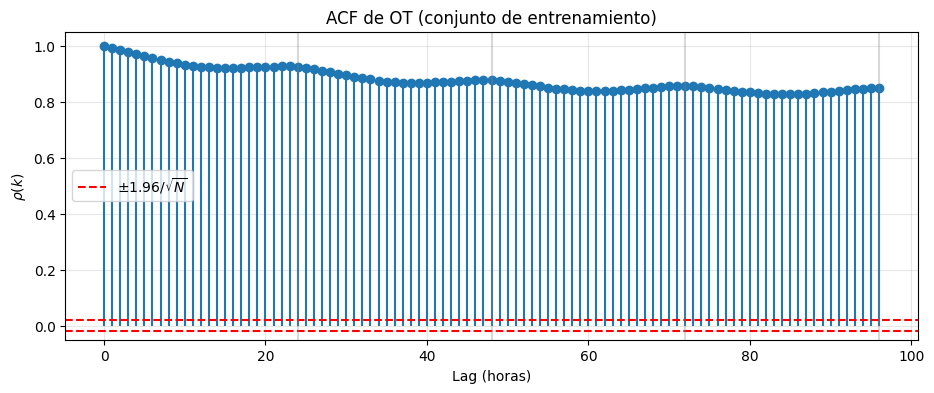

Banda de confianza 95%: ±0.0192
rho( 1) = 0.9923
rho( 6) = 0.9558
rho(12) = 0.9250
rho(22) = 0.9262
rho(24) = 0.9250
rho(36) = 0.8695
rho(47) = 0.8770
rho(48) = 0.8763
rho(72) = 0.8572
rho(84) = 0.8266
rho(96) = 0.8489
Picos locales: [(22, np.float64(0.9262)), (47, np.float64(0.877)), (72, np.float64(0.8572))]


In [4]:
def acf_manual(series, max_lag):
    """ACF para lags 0..max_lag según la fórmula del enunciado."""
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    xc = x - x.mean()                         # (x_t - x̄)
    denom = np.sum(xc ** 2) / N               # (1/N) Σ (x_t - x̄)^2  -> varianza
    rho = np.empty(max_lag + 1)
    for k in range(max_lag + 1):
        # Σ_{t=k}^{N-1} (x_t - x̄)(x_{t-k} - x̄), normalizado por (N-k)
        num = np.sum(xc[k:] * xc[:N - k]) / (N - k)
        rho[k] = num / denom
    return rho

acf_tr = acf_manual(OT_train.numpy(), 96)
conf = 1.96 / np.sqrt(len(OT_train))      # banda de confianza al 95%

plt.figure(figsize=(11, 4))
plt.stem(range(len(acf_tr)), acf_tr, basefmt=" ")
plt.axhline( conf, color="r", ls="--", label=r"$\pm 1.96/\sqrt{N}$")
plt.axhline(-conf, color="r", ls="--")
for k in (24, 48, 72, 96):
    plt.axvline(k, color="gray", alpha=0.3)
plt.xlabel("Lag (horas)"); plt.ylabel(r"$\rho(k)$")
plt.title("ACF de OT (conjunto de entrenamiento)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print(f"Banda de confianza 95%: ±{conf:.4f}")
for k in (1, 6, 12, 22, 24, 36, 47, 48, 72, 84, 96):
    print(f"rho({k:2d}) = {acf_tr[k]:.4f}")

# Picos locales (máximos relativos) después del lag 0
peaks = [k for k in range(2, 96) if acf_tr[k] > acf_tr[k-1] and acf_tr[k] > acf_tr[k+1]]
print("Picos locales:", [(k, round(acf_tr[k], 4)) for k in peaks])

### Interpretación (a) – segundo pico de la ACF

La ACF decae monótonamente desde $\rho(1)\approx0.992$ hasta un valle cerca de lag 12–18 y vuelve a subir, formando el primer máximo local alrededor de lag 22–24 ($\rho(22)\approx0.926$, $\rho(24)\approx0.925$). Los siguientes picos aparecen en lag ≈47 ($0.877$) y ≈72 ($0.857$), separados ~24 h entre sí. Esto indica un ciclo diario. La temperatura del aceite sigue el patrón de carga eléctrica (mayor consumo de día, menor de noche), y la del mismo horario del día anterior es el mejor predictor tras las horas inmediatamente previas. Que el máximo quede en 22 en vez de exactamente 24 se debe a que la curva es muy plana en esa zona (diferencia ≈0.001).

### Justificación (b) – ¿es adecuado L = 96?

- Todos los lags 1–96 están muy por encima de la banda ±0.019, es decir, la serie es muy persistente (tendencia/estacionalidad lenta) y hay información útil en toda la ventana.
- Con $L=96$ la ventana contiene cuatro ciclos diarios completos (picos en 24, 48, 72 y 96), lo que permite al modelo ver varias repeticiones del patrón diario y promediar el ruido de un solo día.
- Los picos decaen lentamente ($0.925 \to 0.877 \to 0.857 \to 0.849$ en lag 96): un día más de historia aporta cada vez menos correlación marginal, y alargar la ventana encarece el LSTM (más pasos secuenciales, gradientes que viajan más lejos) con poco beneficio.
- Una ventana menor a 24 perdería el ciclo diario completo; una de 24–48 captaría solo 1–2 ciclos.

Conclusión: $L=96$ es una elección razonable, aunque podría reducirse a ~48–72 sin perder el patrón diario, pero esto no conviene hacerla mucho mayor dado el decaimiento lento de los picos.

## Verificación Task 1

In [5]:
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.2009)


## Task 2.1 – LSTM implementado manualmente

Ecuaciones de la celda en cada paso $t$:

$$\begin{aligned}
[\tilde i,\tilde f,\tilde g,\tilde o] &= x_t W_x^\top + h_{t-1} W_h^\top + b\\
i_t=\sigma(\tilde i),\quad f_t&=\sigma(\tilde f),\quad g_t=\tanh(\tilde g),\quad o_t=\sigma(\tilde o)\\
c_t &= f_t\odot c_{t-1} + i_t\odot g_t\\
h_t &= o_t\odot\tanh(c_t)\\
\hat y &= h_L W_{out}^\top + b_{out}
\end{aligned}$$

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        k = 1.0 / math.sqrt(d_h)   # misma escala de inicialización que usa PyTorch
        # Pesos de las 4 compuertas apilados en el orden [i, f, g, o]
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in).uniform_(-k, k))  # (4*d_h, d_in)
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h).uniform_(-k, k))   # (4*d_h, d_h)
        b = torch.zeros(4 * d_h)
        b[d_h:2 * d_h] = 1.0   # sesgo de la compuerta de olvido = 1: al inicio f≈0.73,
                               # la celda "recuerda" y el gradiente fluye mejor por c_t
        self.b = nn.Parameter(b)                                            # (4*d_h,)
        # Capa de salida: h_L -> escalar
        self.W_out = nn.Parameter(torch.empty(1, d_h).uniform_(-k, k))      # (1, d_h)
        self.b_out = nn.Parameter(torch.zeros(1))                           # (1,)

    def forward(self, x):
        """
        x    : Tensor (B, L) batch de secuencias univariadas
        pred : Tensor (B,)   predicción escalar por secuencia
        """
        B, L = x.shape
        x = x.reshape(B, L, 1)                                   # 1. (B, L, d_in=1)
        h = torch.zeros(B, self.d_h, device=x.device, dtype=x.dtype)   # 2. h_0 = 0
        c = torch.zeros(B, self.d_h, device=x.device, dtype=x.dtype)   #    c_0 = 0

        for t in range(L):                                       # 3. recurrencia
            # a. preactivaciones de las 4 compuertas: x_t Wx^T + h_{t-1} Wh^T + b
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b      # (B, 4*d_h)
            # b. separar en bloques de tamaño d_h
            i, f, g, o = gates.chunk(4, dim=1)
            # c. no linealidades
            i = torch.sigmoid(i)      # compuerta de entrada
            f = torch.sigmoid(f)      # compuerta de olvido
            g = torch.tanh(g)         # candidato a memoria
            o = torch.sigmoid(o)      # compuerta de salida
            # d. c_t = f ⊙ c_{t-1} + i ⊙ g
            c = f * c + i * g
            # e. h_t = o ⊙ tanh(c_t)
            h = o * torch.tanh(c)

        pred = h @ self.W_out.T + self.b_out                     # 4. (B, 1)
        return pred.squeeze(-1)                                  # 5. (B,)

## Task 2.2 – Entrenamiento

**Función de pérdida:** MSE, $\mathcal L = \frac1N\sum (y-\hat y)^2$. Ver justificación en las preguntas de análisis.

### Diagnóstico: cambio de distribución entre train y validación

Con la formulación directa (predecir el nivel absoluto $x_{t+H}$), el LSTM alcanzó MSE de entrenamiento $\approx0.120$, menor que el naive en train ($\approx0.152$). Sin embargo, en validación obtuvo ratio $\approx1.28$ (peor que el naive).

La celda siguiente muestra la causa: el bloque de entrenamiento (primeros 60%, meses cálidos) tiene media normalizada $0$, mientras que validación está desplazada $\approx-1.2\sigma$ (más fría). El LSTM, con activaciones saturables ($\sigma$, $\tanh$) y un sesgo $b_{out}$ ajustado a train, sesga sus predicciones hacia los niveles de train. El naive $\hat y=x_t$ no sufre este problema porque sigue el nivel actual.

Solución: aprendizaje residual (invariante al nivel). A cada ventana se le resta su último valor $x_t$:

$$\tilde X^{(t)} = X^{(t)} - x_t,\qquad \tilde y^{(t)} = x_{t+H} - x_t,\qquad \hat y^{(t)} = x_t + \text{LSTM}(\tilde X^{(t)})$$

El modelo aprende el *cambio* en las próximas $H$ horas en vez del nivel absoluto, así que un desplazamiento global de la serie no lo afecta. Si la red predice $0$, se recupera exactamente el naive, por lo que el baseline queda como punto de partida. La clase `LSTMForecaster` no cambia; solo cambia qué se le da como entrada y cómo se interpreta su salida.

train: media z = +0.000  min = -2.51  max = +3.37  (media en °C = 17.29)
val  : media z = -1.206  min = -2.47  max = +0.27  (media en °C = 7.02)
test : media z = -1.124  min = -2.14  max = -0.01  (media en °C = 7.72)


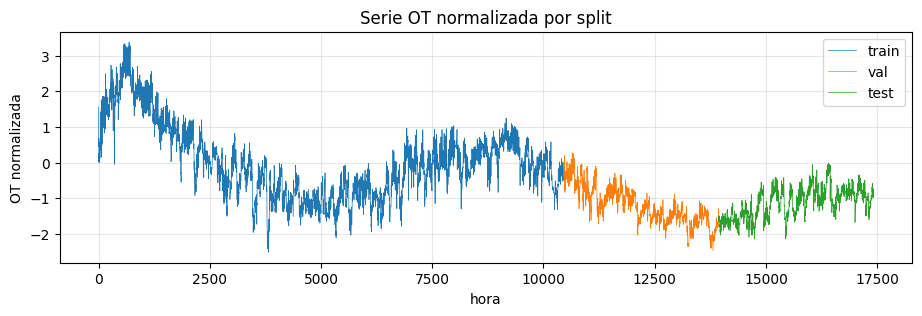

In [7]:
# Diagnóstico del cambio de nivel entre splits
for name, s in [("train", OT_train), ("val", OT_val), ("test", OT_test)]:
    print(f"{name:5s}: media z = {s.mean().item():+.3f}  min = {s.min().item():+.2f}  max = {s.max().item():+.2f}"
          f"  (media en °C = {denorm(s.mean().item()):.2f})")

plt.figure(figsize=(11, 3))
plt.plot(range(n_train), OT_train, lw=0.5, label="train")
plt.plot(range(n_train, n_val), OT_val, lw=0.5, label="val")
plt.plot(range(n_val, N_total), OT_test, lw=0.5, label="test")
plt.ylabel("OT normalizada"); plt.xlabel("hora"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Serie OT normalizada por split"); plt.show()


In [8]:
def to_residual(X):
    """X̃ = X - x_t : la ventana relativa a su último valor. Devuelve (X̃, x_t)."""
    last = X[:, -1]
    return X - last.unsqueeze(1), last

def train_model(model, X, y, epochs=20, batch_size=64, lr=1e-3, clip=1.0, seed=42):
    """Entrena con Adam + MSE sobre el objetivo residual ỹ = x_{t+H} - x_t.
    Devuelve la pérdida media por época."""
    torch.manual_seed(seed)
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    X_rel, last = to_residual(X)
    y_rel = y - last                              # ỹ = x_{t+H} - x_t
    X_rel, y_rel = X_rel.to(device), y_rel.to(device)
    n = X_rel.shape[0]
    history = []
    for ep in range(epochs):
        model.train()
        # Se barajan las VENTANAS de train (no la serie): cada ventana conserva
        # su orden temporal interno, así que no hay fuga de información.
        perm = torch.randperm(n, device=device)
        total = 0.0
        for s in range(0, n, batch_size):
            idx = perm[s:s + batch_size]
            pred = model(X_rel[idx])
            # MSE sobre el residual; como ŷ - y = (x_t + pred) - (x_t + ỹ) = pred - ỹ,
            # es exactamente el MSE sobre la predicción final.
            loss = F.mse_loss(pred, y_rel[idx])
            opt.zero_grad()
            loss.backward()                          # BPTT a través de los L pasos
            # Recorte de norma del gradiente: evita explosión en la BPTT
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total += loss.item() * len(idx)
        history.append(total / n)
        print(f"  época {ep+1:2d}/{epochs}  loss_train={history[-1]:.5f}")
    return history

@torch.no_grad()
def predict(model, X, batch_size=512):
    """ŷ = x_t + LSTM(X - x_t): se devuelve la predicción en la escala normalizada original."""
    model.eval()
    X_rel, last = to_residual(X)
    out = [model(X_rel[s:s + batch_size].to(device)).cpu() for s in range(0, len(X), batch_size)]
    return last + torch.cat(out)

def metrics(y, pred, X):
    """MAE, RMSE (en unidades normalizadas y en °C) y ratio vs naive (ŷ = x_t)."""
    mae  = torch.abs(y - pred).mean().item()
    rmse = torch.sqrt(((y - pred) ** 2).mean()).item()
    naive = torch.abs(y - X[:, -1]).mean().item()
    return {"MAE": mae, "RMSE": rmse, "MAE_°C": mae * sigma, "RMSE_°C": rmse * sigma,
            "naive_MAE": naive, "ratio": mae / naive}


In [9]:
print("Entrenando LSTM H=24")
lstm_24 = LSTMForecaster(d_in=1, d_h=32)
hist_lstm_24 = train_model(lstm_24, X_tr_24, y_tr_24)

print("\nEntrenando LSTM H=48")
lstm_48 = LSTMForecaster(d_in=1, d_h=32)
hist_lstm_48 = train_model(lstm_48, X_tr_48, y_tr_48)

Entrenando LSTM H=24


  época  1/20  loss_train=0.14373


  época  2/20  loss_train=0.13784


  época  3/20  loss_train=0.13667


  época  4/20  loss_train=0.13518


...

  época 16/20  loss_train=0.19543


  época 17/20  loss_train=0.19565


  época 18/20  loss_train=0.19340


  época 19/20  loss_train=0.19434


  época 20/20  loss_train=0.19298


In [10]:
pred_vl_24 = predict(lstm_24, X_vl_24)
pred_vl_48 = predict(lstm_48, X_vl_48)

res_lstm_24 = metrics(y_vl_24, pred_vl_24, X_vl_24)
res_lstm_48 = metrics(y_vl_48, pred_vl_48, X_vl_48)

print(f"{'Modelo':<12}{'H':>4}{'MAE':>9}{'RMSE':>9}{'MAE °C':>9}{'RMSE °C':>9}{'ratio':>8}")
for name, H, r in [("LSTM", 24, res_lstm_24), ("LSTM", 48, res_lstm_48)]:
    print(f"{name:<12}{H:>4}{r['MAE']:>9.4f}{r['RMSE']:>9.4f}{r['MAE_°C']:>9.3f}{r['RMSE_°C']:>9.3f}{r['ratio']:>8.3f}")
for H, X, y in [(24, X_vl_24, y_vl_24), (48, X_vl_48, y_vl_48)]:
    naive = X[:, -1]
    mae = torch.abs(y - naive).mean().item(); rmse = torch.sqrt(((y - naive) ** 2).mean()).item()
    print(f"{'Naive':<12}{H:>4}{mae:>9.4f}{rmse:>9.4f}{mae*sigma:>9.3f}{rmse*sigma:>9.3f}{1.0:>8.3f}")

Modelo         H      MAE     RMSE   MAE °C  RMSE °C   ratio
LSTM          24   0.2098   0.2618    1.786    2.229   1.044
LSTM          48   0.2529   0.3150    2.153    2.682   0.965
Naive         24   0.2009   0.2689    1.710    2.289   1.000
Naive         48   0.2620   0.3380    2.231    2.878   1.000


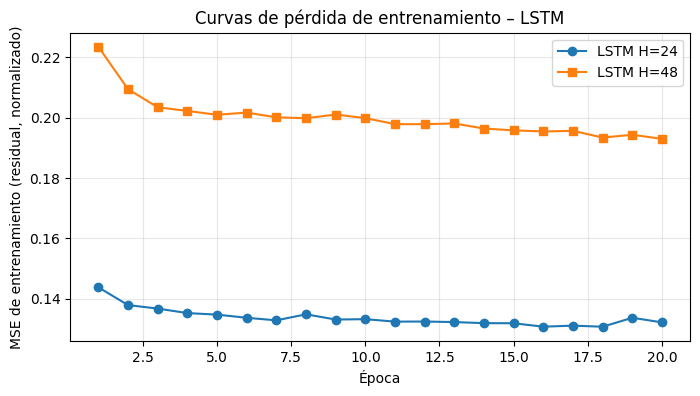

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), hist_lstm_24, "o-", label="LSTM H=24")
plt.plot(range(1, 21), hist_lstm_48, "s-", label="LSTM H=48")
plt.xlabel("Época"); plt.ylabel("MSE de entrenamiento (residual, normalizado)")
plt.title("Curvas de pérdida de entrenamiento – LSTM")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## Verificación Task 2

In [12]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.2098, ratio=1.044


## Task 3.1 – Positional encoding y proyección de entrada

Cada paso de la ventana es un escalar $x_t\in\mathbb R$. Primero se proyecta a $\mathbb R^{d_{model}}$ con `nn.Linear(1, d_model)` y luego se le suma el positional encoding sinusoidal de Vaswani et al. (2017):

$$\mathrm{PE}(t,2i)=\sin\!\left(\frac{t}{10000^{2i/d_{model}}}\right),\qquad \mathrm{PE}(t,2i+1)=\cos\!\left(\frac{t}{10000^{2i/d_{model}}}\right)$$

El PE no es aprendible: se guarda como *buffer* del módulo (se mueve con `.to(device)` pero no recibe gradiente).

PE shape: (96, 32) | requires_grad: False


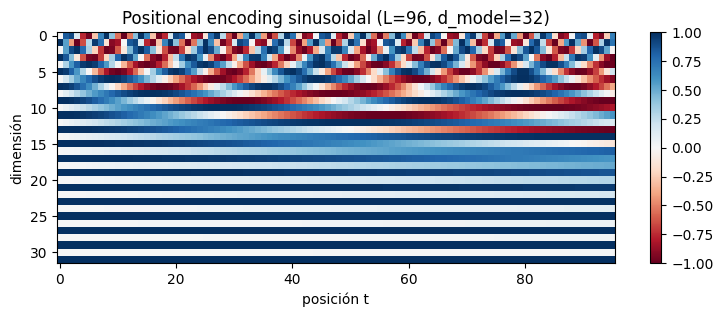

In [13]:
def make_pe(max_len, d_model):
    """Positional encoding sinusoidal (Vaswani et al., 2017). Retorna (max_len, d_model), sin gradiente."""
    t = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)          # posición t: (L, 1)
    two_i = torch.arange(0, d_model, 2, dtype=torch.float32)             # índices pares 2i
    div = torch.pow(10000.0, two_i / d_model)                            # 10000^{2i/d_model}
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(t / div)                                     # PE(t, 2i)
    pe[:, 1::2] = torch.cos(t / div)                                     # PE(t, 2i+1)
    return pe                                                            # requires_grad = False

_pe = make_pe(96, 32)
print("PE shape:", tuple(_pe.shape), "| requires_grad:", _pe.requires_grad)

plt.figure(figsize=(9, 3))
plt.imshow(_pe.T, aspect="auto", cmap="RdBu")
plt.xlabel("posición t"); plt.ylabel("dimensión"); plt.colorbar()
plt.title("Positional encoding sinusoidal (L=96, d_model=32)"); plt.show()

## Task 3.2 – TransformerForecaster con multi-head self-attention manual

Un bloque encoder (post-norm) implementado con tensores:

$$\begin{aligned}
Q&=XW_Q,\quad K=XW_K,\quad V=XW_V\\
\text{head}_h&=\mathrm{softmax}\!\left(\frac{Q_hK_h^\top}{\sqrt{d_k}}\right)V_h,\qquad d_k=d_{model}/n_{heads}\\
\mathrm{MHA}(X)&=[\text{head}_1\,\|\,\dots\,\|\,\text{head}_H]\,W_O\\
X'&=\mathrm{LN}(X+\mathrm{MHA}(X)),\qquad X''=\mathrm{LN}(X'+\mathrm{FFN}(X'))\\
\mathrm{FFN}(x)&=\mathrm{ReLU}(xW_1+b_1)W_2+b_2,\qquad \mathrm{LN}(x)=\gamma\odot\frac{x-\mu}{\sqrt{\sigma^2+\varepsilon}}+\beta\\
\hat y&=W_{out}\,X''_{[0]}\quad\text{(posición 0 como token CLS)}
\end{aligned}$$

In [14]:
class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L

        def xavier(*shape):
            return nn.Parameter(nn.init.xavier_uniform_(torch.empty(*shape)))

        # Proyección de entrada: escalar x_t -> R^{d_model}
        self.input_proj = nn.Linear(1, d_model)
        # PE fijo (no aprendible): buffer
        self.register_buffer("PE", make_pe(L, d_model))
        # Proyecciones de atención (se usan como x @ W)
        self.WQ = xavier(d_model, d_model)
        self.WK = xavier(d_model, d_model)
        self.WV = xavier(d_model, d_model)
        self.WO = xavier(d_model, d_model)
        # FFN
        self.W1 = xavier(d_model, d_ff);  self.b1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = xavier(d_ff, d_model);  self.b2 = nn.Parameter(torch.zeros(d_model))
        # LayerNorm aprendible (gamma = 1, beta = 0 al inicio)
        self.gamma1 = nn.Parameter(torch.ones(d_model));  self.beta1 = nn.Parameter(torch.zeros(d_model))
        self.gamma2 = nn.Parameter(torch.ones(d_model));  self.beta2 = nn.Parameter(torch.zeros(d_model))
        # Cabeza de salida
        self.W_out = nn.Linear(d_model, 1)

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        """LN(x) = gamma * (x - mu) / sqrt(var + eps) + beta, sobre la última dimensión."""
        mu = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return gamma * (x - mu) / torch.sqrt(var + eps) + beta

    def multi_head_attention(self, x):
        """
        x      : (B, L, d_model)
        out    : (B, L, d_model)
        attn_w : (B, n_heads, L, L)
        """
        B, L, _ = x.shape
        # 1. Q = X WQ, K = X WK, V = X WV : (B, L, d_model)
        Q, K, V = x @ self.WQ, x @ self.WK, x @ self.WV
        # 2. separar cabezas: (B, L, n_heads, d_k) -> (B, n_heads, L, d_k)
        split = lambda T: T.reshape(B, L, self.n_heads, self.d_k).transpose(1, 2)
        Q, K, V = split(Q), split(K), split(V)
        # 3. scores e_ts = q_t · k_s / sqrt(d_k) : (B, n_heads, L, L)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        # 4. softmax sobre las posiciones s (cada fila suma 1)
        attn_w = torch.softmax(scores, dim=-1)
        # 5. suma ponderada de valores: (B, n_heads, L, d_k)
        out = attn_w @ V
        # 6. concatenar cabezas -> (B, L, d_model) y proyectar con WO
        out = out.transpose(1, 2).reshape(B, L, self.d_model) @ self.WO
        return out, attn_w

    def feed_forward(self, x):
        """FFN(x) = ReLU(x W1 + b1) W2 + b2, aplicada posición por posición."""
        return torch.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, return_attn=False):
        """
        x : (B, L)  ->  pred : (B,)   [y attn_w : (B, n_heads, L, L) si return_attn]
        """
        L = x.shape[1]
        # 1. embedding de entrada + positional encoding
        h = self.input_proj(x.unsqueeze(-1)) + self.PE[:L]        # (B, L, d_model)
        # 2-3. self-attention + Add & Norm
        att_out, attn_w = self.multi_head_attention(h)
        h = self.layer_norm(h + att_out, self.gamma1, self.beta1)
        # 4-5. FFN + Add & Norm
        ff_out = self.feed_forward(h)
        h = self.layer_norm(h + ff_out, self.gamma2, self.beta2)
        # 6. posición 0 como token CLS
        pred = self.W_out(h[:, 0, :]).squeeze(-1)                 # (B,)
        return (pred, attn_w) if return_attn else pred

_trf = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
print("Parámetros entrenables Transformer:", sum(p.numel() for p in _trf.parameters() if p.requires_grad))
print("Parámetros entrenables LSTM       :", sum(p.numel() for p in LSTMForecaster(1, 32).parameters()))

Parámetros entrenables Transformer: 8513
Parámetros entrenables LSTM       : 4385


## Task 3.3 – Entrenamiento del Transformer

Mismas condiciones que el LSTM: Adam ($lr=10^{-3}$), 20 épocas, `batch_size=64`, MSE, recorte de gradiente a 1.0 y la **misma formulación residual** ($\tilde X = X - x_t$, $\hat y = x_t + f(\tilde X)$), para que la comparación sea justa. Se reutilizan `train_model`, `predict` y `metrics` del Task 2.

In [15]:
print("Entrenando Transformer H=24")
trf_24 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
hist_trf_24 = train_model(trf_24, X_tr_24, y_tr_24)

print("\nEntrenando Transformer H=48")
trf_48 = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
hist_trf_48 = train_model(trf_48, X_tr_48, y_tr_48)

Entrenando Transformer H=24


  época  1/20  loss_train=0.13922


  época  2/20  loss_train=0.13284


  época  3/20  loss_train=0.13344


  época  4/20  loss_train=0.13244


...

  época 16/20  loss_train=0.18419


  época 17/20  loss_train=0.18395


  época 18/20  loss_train=0.18216


  época 19/20  loss_train=0.18233


  época 20/20  loss_train=0.18140


Validación
Modelo         H      MAE     RMSE   MAE °C  RMSE °C   ratio
LSTM          24   0.2098   0.2618    1.786    2.229   1.044
LSTM          48   0.2529   0.3150    2.153    2.682   0.965
Transformer   24   0.2245   0.2737    1.912    2.330   1.118
Transformer   48   0.2436   0.3148    2.074    2.680   0.930
Naive         24   0.2009   0.2689    1.710    2.289   1.000
Naive         48   0.2620   0.3380    2.231    2.878   1.000


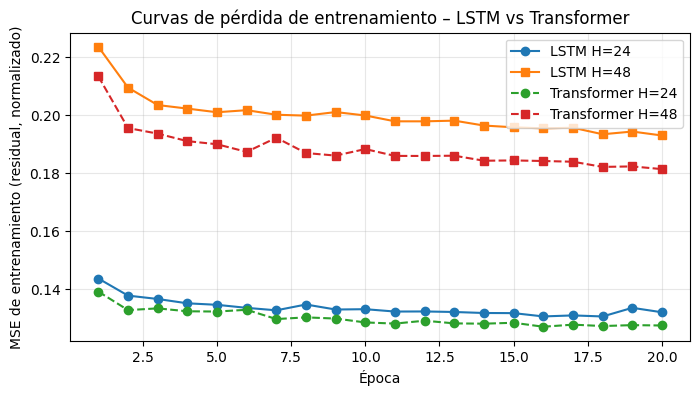

In [16]:
pred_trf_vl_24 = predict(trf_24, X_vl_24)
pred_trf_vl_48 = predict(trf_48, X_vl_48)
res_trf_24 = metrics(y_vl_24, pred_trf_vl_24, X_vl_24)
res_trf_48 = metrics(y_vl_48, pred_trf_vl_48, X_vl_48)

def naive_metrics(X, y):
    return metrics(y, X[:, -1], X)

res_naive_24 = naive_metrics(X_vl_24, y_vl_24)
res_naive_48 = naive_metrics(X_vl_48, y_vl_48)

print("Validación")
print(f"{'Modelo':<12}{'H':>4}{'MAE':>9}{'RMSE':>9}{'MAE °C':>9}{'RMSE °C':>9}{'ratio':>8}")
for name, H, r in [("LSTM", 24, res_lstm_24), ("LSTM", 48, res_lstm_48),
                   ("Transformer", 24, res_trf_24), ("Transformer", 48, res_trf_48),
                   ("Naive", 24, res_naive_24), ("Naive", 48, res_naive_48)]:
    print(f"{name:<12}{H:>4}{r['MAE']:>9.4f}{r['RMSE']:>9.4f}{r['MAE_°C']:>9.3f}{r['RMSE_°C']:>9.3f}{r['ratio']:>8.3f}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), hist_lstm_24, "o-", label="LSTM H=24")
plt.plot(range(1, 21), hist_lstm_48, "s-", label="LSTM H=48")
plt.plot(range(1, 21), hist_trf_24, "o--", label="Transformer H=24")
plt.plot(range(1, 21), hist_trf_48, "s--", label="Transformer H=48")
plt.xlabel("Época"); plt.ylabel("MSE de entrenamiento (residual, normalizado)")
plt.title("Curvas de pérdida de entrenamiento – LSTM vs Transformer")
plt.legend(); plt.grid(alpha=0.3); plt.show()

### b) Resultados del Transformer (validación)

| Modelo | H | MAE | RMSE | MAE (°C) | RMSE (°C) | Ratio vs naive |
|---|---|---|---|---|---|---|
| Transformer | 24 | 0.2245 | 0.2737 | 1.912 | 2.330 | 1.118 |
| Transformer | 48 | 0.2436 | 0.3148 | 2.074 | 2.680 | **0.930** |

- **H = 24:** el Transformer no supera al naive (ratio 1.118) ni al LSTM (1.044). Su pérdida de entrenamiento final es *menor* que la del LSTM (0.1275 vs 0.1321), pero en validación es peor: con casi el doble de parámetros (8,513 vs 4,385) sobreajusta a la dinámica de train, que tiene otro nivel y otra variabilidad que validación.
- **H = 48:** es el mejor modelo (ratio 0.930, MAE 2.07 °C frente a 2.15 °C del LSTM y 2.23 °C del naive). En RMSE empata con el LSTM (0.3148 vs 0.3150).

### c) y d) Mapas de atención

Se toman 5 ventanas de validación espaciadas uniformemente (para no elegir 5 ventanas consecutivas casi idénticas), se promedia sobre los 5 ejemplos y las 2 cabezas y se grafica el mapa $(L, L)$. Luego se extrae la fila 0 (el token CLS) y se convierte cada posición $j$ a lag: $\text{lag} = L - j$ (posición 95 → lag 1, el valor más reciente; posición 0 → lag 96, el más antiguo).

Índices de validación usados: [0, 835, 1670, 2505, 3340]


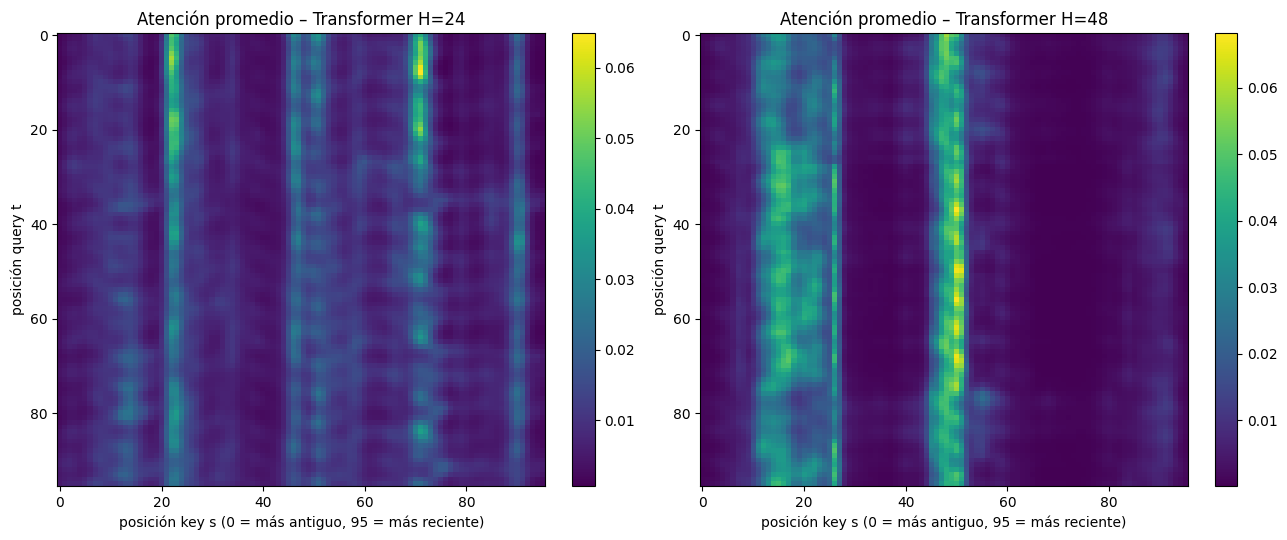

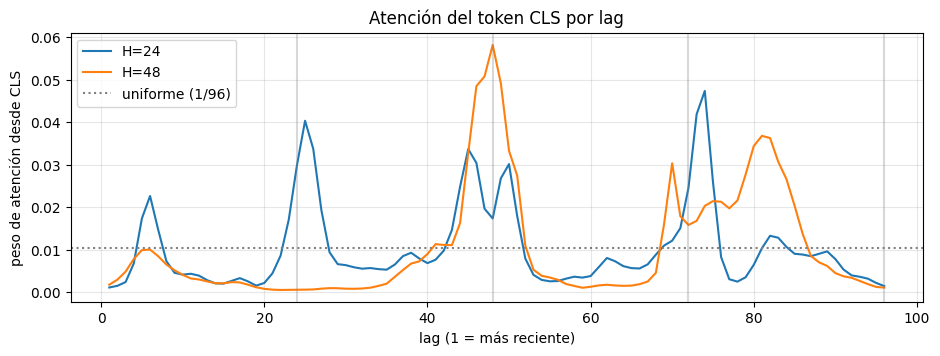

H=24: top-10 lags con mayor atención desde CLS
    [(74, 0.0474), (73, 0.0419), (25, 0.0404), (26, 0.0338), (45, 0.0337), (46, 0.0305), (50, 0.0302), (24, 0.0299), (49, 0.0268), (75, 0.026)]
    masa de atención en lags 1-12: 0.091 | lags 85-96: 0.073 | máx/uniforme = 4.55
H=48: top-10 lags con mayor atención desde CLS
    [(48, 0.0582), (47, 0.0508), (49, 0.0492), (46, 0.0485), (81, 0.0368), (82, 0.0363), (80, 0.0344), (50, 0.0333), (45, 0.0328), (83, 0.0308)]
    masa de atención en lags 1-12: 0.068 | lags 85-96: 0.075 | máx/uniforme = 5.59


In [17]:
@torch.no_grad()
def get_attention(model, X):
    """Pesos de atención (B, n_heads, L, L) sobre la entrada residual, igual que en predict()."""
    model.eval()
    X_rel, _ = to_residual(X)
    _, attn = model(X_rel.to(device), return_attn=True)
    return attn.cpu()

idx5 = torch.linspace(0, min(len(X_vl_24), len(X_vl_48)) - 1, 5).long()
print("Índices de validación usados:", idx5.tolist())

attn_24 = get_attention(trf_24, X_vl_24[idx5]).mean(dim=(0, 1))    # (L, L) promedio 5 ejemplos × 2 cabezas
attn_48 = get_attention(trf_48, X_vl_48[idx5]).mean(dim=(0, 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, A, H in zip(axes, (attn_24, attn_48), (24, 48)):
    im = ax.imshow(A, cmap="viridis", aspect="auto")
    ax.set_title(f"Atención promedio – Transformer H={H}")
    ax.set_xlabel("posición key s (0 = más antiguo, 95 = más reciente)")
    ax.set_ylabel("posición query t")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

L_ = 96
lags = np.arange(L_, 0, -1)                 # lags[j] = L - j
cls_24 = attn_24[0].numpy()                 # fila del token CLS
cls_48 = attn_48[0].numpy()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(lags, cls_24, label="H=24")
ax.plot(lags, cls_48, label="H=48")
ax.axhline(1 / L_, color="gray", ls=":", label="uniforme (1/96)")
for k in (24, 48, 72, 96):
    ax.axvline(k, color="gray", alpha=0.3)
ax.set_xlabel("lag (1 = más reciente)"); ax.set_ylabel("peso de atención desde CLS")
ax.set_title("Atención del token CLS por lag"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

for H, row in ((24, cls_24), (48, cls_48)):
    order = np.argsort(row)[::-1][:10]
    print(f"H={H}: top-10 lags con mayor atención desde CLS")
    print("   ", [(int(lags[j]), round(float(row[j]), 4)) for j in order])
    print(f"    masa de atención en lags 1-12: {row[lags <= 12].sum():.3f} | lags 85-96: {row[lags >= 85].sum():.3f}"
          f" | máx/uniforme = {row.max() * L_:.2f}")

### d) Posiciones con mayor atención desde el token CLS

Convención: posición $j$ → lag $=96-j$ (lag 1 = $x_t$, el valor más reciente; lag 96 = el más antiguo, que es la propia posición CLS).

- **H = 24:** los mayores pesos están en los lags **74 (0.047), 73 (0.042), 25 (0.040), 26 (0.034), 45–46 (0.034, 0.031), 50, 24, 49**. Forman tres bandas separadas ~24 h: **24–26, 45–50 y 73–75**. El heatmap muestra que casi todas las filas (queries) atienden a esas mismas columnas.
- **H = 48:** la atención se concentra en los lags **46–50** (máximo en lag 48, 0.058) y una segunda banda en **80–83**.
- En ambos modelos, los lags 1–3 reciben casi nada (≈0.001–0.005, por debajo del uniforme 1/96 ≈ 0.010) y el pico máximo es 4.5–5.6 veces el peso uniforme: la atención es selectiva, no difusa.

## Verificación Task 3

In [18]:
# Verificar shapes
_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
assert _pred_test.shape == (4,), \
    f"pred shape incorrecto: {_pred_test.shape}"
assert _attn_test.shape == (4, 2, 96, 96), \
    f"attn shape incorrecto: {_attn_test.shape}"

# Verificar que la atencion suma 1 por fila
row_sums = _attn_test[0, 0].sum(-1)
assert torch.allclose(row_sums, torch.ones(96), atol=1e-4), \
    "Los pesos de atencion no suman 1 por fila"

print(f"Task 3: CORRECTO")
print(f"  attn_w shape: {_attn_test.shape}")
print(f"  row sums OK: {row_sums.min().item():.4f} a {row_sums.max().item():.4f}")

Task 3: CORRECTO
  attn_w shape: torch.Size([4, 2, 96, 96])
  row sums OK: 1.0000 a 1.0000


## Task 4.1 – ACF vs. atención

Para que la comparación sea robusta se calcula la atención del CLS por lag no solo con los 5 ejemplos, sino también promediando sobre **todo** el conjunto de validación. Se comparan con la ACF del Task 1.2 en los mismos lags.

 lag      ACF   att H=24  rank24   att H=48  rank48
   1   0.9923     0.0011      96     0.0017      84
   2   0.9849     0.0013      95     0.0027      65
   3   0.9773     0.0022      89     0.0050      50
   6   0.9558     0.0218      13     0.0106      33
  12   0.9250     0.0036      75     0.0030      59
  22   0.9262     0.0079      38     0.0012      93
  24   0.9250     0.0328       6     0.0014      88
  36   0.8695     0.0071      47     0.0038      54
  47   0.8770     0.0192      15     0.0398       4
  48   0.8763     0.0168      17     0.0463       3
  72   0.8572     0.0256      11     0.0158      24
  84   0.8266     0.0089      32     0.0217      16
  96   0.8489     0.0014      94     0.0013      91

Correlación de Pearson (lags 1..96) ACF vs atención: H=24 +0.018 | H=48 -0.279
Top-5 lags por atención (toda validación) H=24: [74, 25, 73, 26, 45]
Top-5 lags por atención (toda validación) H=48: [49, 50, 48, 47, 46]
Picos locales de la ACF: [22, 47, 72]


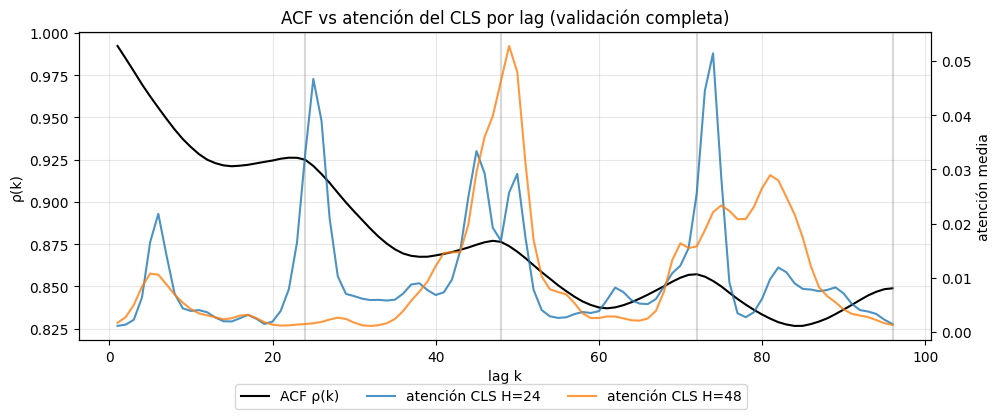

H=24: |corr(ỹ, x̃_lag)| más altas (train): [(73, 0.322), (72, 0.32), (74, 0.32), (71, 0.319), (70, 0.317), (75, 0.316), (69, 0.314), (76, 0.313)]
H=48: |corr(ỹ, x̃_lag)| más altas (train): [(96, 0.41), (95, 0.405), (94, 0.401), (93, 0.395), (49, 0.392), (50, 0.392), (92, 0.39), (51, 0.389)]


In [19]:
@torch.no_grad()
def cls_attention_all(model, X, bs=512):
    """Atención del CLS (fila 0), promediada sobre cabezas, para cada ventana: (N, L)."""
    rows = [get_attention(model, X[s:s + bs])[:, :, 0, :].mean(1) for s in range(0, len(X), bs)]
    return torch.cat(rows).numpy()

cls_all_24 = cls_attention_all(trf_24, X_vl_24)
cls_all_48 = cls_attention_all(trf_48, X_vl_48)
m24, m48 = cls_all_24.mean(0), cls_all_48.mean(0)
att_by_lag_24 = {int(lags[j]): m24[j] for j in range(L_)}
att_by_lag_48 = {int(lags[j]): m48[j] for j in range(L_)}

print(f"{'lag':>4}{'ACF':>9}{'att H=24':>11}{'rank24':>8}{'att H=48':>11}{'rank48':>8}")
rank24 = {int(lags[j]): r + 1 for r, j in enumerate(np.argsort(m24)[::-1])}
rank48 = {int(lags[j]): r + 1 for r, j in enumerate(np.argsort(m48)[::-1])}
for k in (1, 2, 3, 6, 12, 22, 24, 36, 47, 48, 72, 84, 96):
    print(f"{k:>4}{acf_tr[k]:>9.4f}{att_by_lag_24[k]:>11.4f}{rank24[k]:>8}{att_by_lag_48[k]:>11.4f}{rank48[k]:>8}")

acf_vec = np.array([acf_tr[k] for k in range(1, 97)])
att_vec_24 = np.array([att_by_lag_24[k] for k in range(1, 97)])
att_vec_48 = np.array([att_by_lag_48[k] for k in range(1, 97)])
print(f"\nCorrelación de Pearson (lags 1..96) ACF vs atención: H=24 {np.corrcoef(acf_vec, att_vec_24)[0,1]:+.3f}"
      f" | H=48 {np.corrcoef(acf_vec, att_vec_48)[0,1]:+.3f}")
print("Top-5 lags por atención (toda validación) H=24:", [int(lags[j]) for j in np.argsort(m24)[::-1][:5]])
print("Top-5 lags por atención (toda validación) H=48:", [int(lags[j]) for j in np.argsort(m48)[::-1][:5]])
print("Picos locales de la ACF:", peaks)

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(range(1, 97), acf_vec, "k-", label="ACF ρ(k)")
ax1.set_xlabel("lag k"); ax1.set_ylabel("ρ(k)")
ax2 = ax1.twinx()
ax2.plot(range(1, 97), att_vec_24, "C0-", alpha=0.8, label="atención CLS H=24")
ax2.plot(range(1, 97), att_vec_48, "C1-", alpha=0.8, label="atención CLS H=48")
ax2.set_ylabel("atención media")
for k in (24, 48, 72, 96):
    ax1.axvline(k, color="gray", alpha=0.3)
fig.legend(loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.08)); ax1.grid(alpha=0.3)
ax1.set_title("ACF vs atención del CLS por lag (validación completa)"); plt.show()

# Correlación entre el OBJETIVO residual ỹ = x_{t+H} - x_t y cada entrada residual x̃ (lag ℓ = x_{t-ℓ+1} - x_t)
# en entrenamiento: qué posiciones son informativas para lo que el modelo realmente predice.
for H, (X, y) in ((24, (X_tr_24, y_tr_24)), (48, (X_tr_48, y_tr_48))):
    Xr, last = to_residual(X); yr = (y - last).numpy(); Xr = Xr.numpy()
    cc = np.array([np.corrcoef(Xr[:, j], yr)[0, 1] for j in range(L_ - 1)])   # sin lag 1 (x̃ ≡ 0)
    lg = lags[:L_ - 1]
    top = np.argsort(np.abs(cc))[::-1][:8]
    print(f"H={H}: |corr(ỹ, x̃_lag)| más altas (train):", [(int(lg[j]), round(float(cc[j]), 3)) for j in top])

### a) ¿Coinciden los lags con mayor atención con los picos de la ACF?

**En periodicidad sí; en el orden de importancia no.**

| lag | 1 | 2 | 3 | 6 | 12 | 22 | 24 | 36 | 47 | 48 | 72 | 84 | 96 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| ACF ρ(k) | 0.992 | 0.985 | 0.977 | 0.956 | 0.925 | 0.926 | 0.925 | 0.870 | 0.877 | 0.876 | 0.857 | 0.827 | 0.849 |
| atención H=24 | 0.0011 | 0.0013 | 0.0022 | 0.0218 | 0.0036 | 0.0079 | 0.0328 | 0.0071 | 0.0192 | 0.0168 | 0.0256 | 0.0089 | 0.0014 |
| atención H=48 | 0.0017 | 0.0027 | 0.0050 | 0.0106 | 0.0030 | 0.0012 | 0.0014 | 0.0038 | 0.0398 | 0.0463 | 0.0158 | 0.0217 | 0.0013 |

(atención media del CLS sobre toda la validación; top-5 H=24: 74, 25, 73, 26, 45; top-5 H=48: 49, 50, 48, 47, 46)

- **Coinciden en el periodo de 24 h.** Los picos de atención de H=24 (≈25, ≈49, ≈74) están separados 24 h igual que los máximos locales de la ACF (22–24, 47, 72). Con la convención del enunciado, el lag ℓ de la atención es $x_{t-\ell+1}$, así que lag 25 = $x_{t-24}$ y lag 49 = $x_{t-48}$: son exactamente los puntos a distancia 24 y 48 del último valor, es decir, los mismos desfases donde la ACF tiene sus picos diarios. Además, son las horas **del mismo momento del día que el objetivo** $x_{t+24}$ (distancia 48, 72 y 96 h).
- **No coinciden en magnitud.** La ACF es máxima en los lags 1–3 (0.99), pero esos lags son los que *menos* atención reciben (rank 89–96 de 96). La correlación de Pearson entre el perfil de ACF y el de atención es prácticamente nula (+0.02 en H=24 y −0.28 en H=48).

**Hipótesis de por qué el Transformer aprendió otro patrón:**
1. **El modelo no predice lo mismo que mide la ACF.** Con la formulación residual predice el cambio $\tilde y = x_{t+H}-x_t$, y el nivel $x_t$ se suma fuera de la red. La ACF mide cuánto se parece $x_{t-k}$ a $x_t$; lo que sirve al modelo es cuánto informa $x_{t-k}$ sobre el *cambio* futuro. Se midió directamente en train: las mayores $|\mathrm{corr}(\tilde y, \tilde x_\ell)|$ para H=24 están en los lags **69–76 (≈0.32)**, justo donde está el pico principal de atención (73–74); para H=48 en los lags **92–96 y 49–51 (≈0.39–0.41)**, y la atención de H=48 se concentra en 46–50.
2. **Los lags recientes son redundantes.** $\tilde x$ en lag 1 vale 0 siempre y en lags 2–3 es casi 0: no aportan información nueva. La ACF alta en esos lags solo refleja persistencia, que ya está en $x_t$.
3. **El softmax compite.** Como los pesos suman 1, el modelo reparte la atención entre pocas posiciones que no son redundantes entre sí (un punto por ciclo diario) en vez de copiar el perfil suave de la ACF.

### Evidencia de dependencia no lineal / dependiente del contenido

La ACF es un número fijo por lag. En la atención, el peso que el CLS asigna a cada posición depende de los **valores** de la ventana ($e_{ts}=q_t^\top k_s/\sqrt{d_k}$ con $q,k$ funciones del input). Si la atención fuera solo posicional (lineal-estacionaria como la ACF), sería casi idéntica en todas las ventanas. Se mide:

1. La variabilidad de la atención entre ventanas (coeficiente de variación por posición y distancia media entre ventanas).
2. Si la atención se concentra en posiciones con valores extremos o con cambios bruscos (correlación, dentro de cada ventana, entre el peso de atención y $|\tilde x_s|$ o $|x_s - x_{s-1}|$).

H=24: CV medio por posición = 0.349 | distancia TV media al patrón medio = 0.105


      corr(atención, |x̃_s|) media por ventana = -0.032 | corr(atención, |Δx_s|) = +0.014 | corr(atención, x̃_s) = +0.045
H=48: CV medio por posición = 0.877 | distancia TV media al patrón medio = 0.227


      corr(atención, |x̃_s|) media por ventana = +0.054 | corr(atención, |Δx_s|) = +0.028 | corr(atención, x̃_s) = +0.133


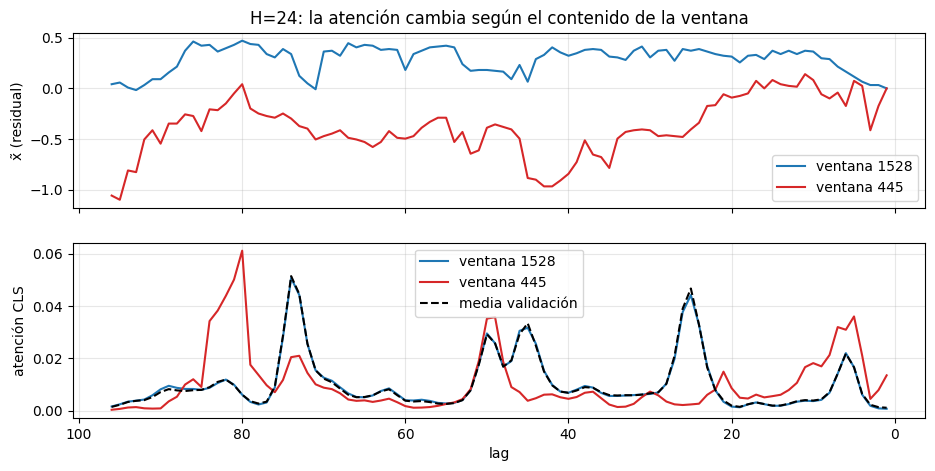

In [20]:
def content_dependence(cls_all, X, name):
    A = cls_all                                           # (N, L)
    cv = A.std(0) / A.mean(0)                             # variación entre ventanas por posición
    tv = 0.5 * np.abs(A - A.mean(0)).sum(1)               # distancia (variación total) al patrón medio
    X_rel = (X - X[:, -1:]).numpy()                       # entrada residual
    dx = np.abs(np.diff(X.numpy(), axis=1, prepend=X.numpy()[:, :1]))
    def mean_within_corr(F):
        c = [np.corrcoef(A[i], F[i])[0, 1] for i in range(len(A)) if F[i].std() > 0]
        return np.nanmean(c)
    print(f"{name}: CV medio por posición = {cv.mean():.3f} | distancia TV media al patrón medio = {tv.mean():.3f}")
    print(f"      corr(atención, |x̃_s|) media por ventana = {mean_within_corr(np.abs(X_rel)):+.3f}"
          f" | corr(atención, |Δx_s|) = {mean_within_corr(dx):+.3f}"
          f" | corr(atención, x̃_s) = {mean_within_corr(X_rel):+.3f}")
    return tv

tv24 = content_dependence(cls_all_24, X_vl_24, "H=24")
tv48 = content_dependence(cls_all_48, X_vl_48, "H=48")

# Ejemplo: dos ventanas con patrón de atención muy distinto
j_lo, j_hi = np.argmin(tv24), np.argmax(tv24)
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
for j, c in ((j_lo, "C0"), (j_hi, "C3")):
    axes[0].plot(lags, (X_vl_24[j] - X_vl_24[j, -1]).numpy(), c, label=f"ventana {j}")
    axes[1].plot(lags, cls_all_24[j], c, label=f"ventana {j}")
axes[1].plot(lags, cls_all_24.mean(0), "k--", label="media validación")
axes[0].set_ylabel("x̃ (residual)"); axes[1].set_ylabel("atención CLS")
axes[1].set_xlabel("lag"); axes[0].invert_xaxis()
for a in axes: a.legend(); a.grid(alpha=0.3)
axes[0].set_title("H=24: la atención cambia según el contenido de la ventana"); plt.show()

### b) Dependencias que el Transformer puede capturar y la ACF no

La ACF resume la dependencia con **un solo número fijo por lag**, $\rho(k)$: es lineal, simétrica e igual para toda la serie (asume estacionariedad). En la atención, $e_{ts}=q_t^\top k_s/\sqrt{d_k}$ con $q_t = W_Q^\top h_t$ y $k_s=W_K^\top h_s$, donde $h$ depende del valor y de la posición. Después pasa por softmax, LayerNorm y la FFN con ReLU. Eso permite capturar:

- **Dependencia condicionada al contenido (no estacionaria):** qué parte del pasado importa según el estado actual (por ejemplo, mirar el día anterior solo cuando hubo un cambio brusco, o distinto de día que de noche).
- **Interacciones entre varios pasos:** combinaciones como $x_{t-24}-x_{t-48}$ (tendencia día a día) o umbrales, que no son correlaciones de pares.
- **Relaciones no lineales o no monótonas** entre $x_{t-k}$ y el objetivo, que dan $\rho\approx0$ aunque haya dependencia fuerte.

**Evidencia en los mapas:**
- Si la atención fuera solo posicional (como la ACF), sería la misma para todas las ventanas. No lo es: el coeficiente de variación del peso por posición entre ventanas es **0.35 (H=24)** y **0.88 (H=48)**, y la distancia media de variación total entre el mapa de cada ventana y el patrón medio es 0.105 y 0.227.
- En la figura de ejemplo, la ventana 445, más irregular (sube ≈0.8σ entre los lags 96 y 85 y cae ≈0.5σ cerca del lag 45), desplaza la atención hacia los lags 78–85 y 5–15, mientras que una ventana tranquila (1528) reproduce el patrón medio. Es decir, el modelo cambia a dónde mira según la forma de la ventana.
- La evidencia es moderada: la dependencia del contenido no es una regla simple de magnitud. La correlación dentro de cada ventana entre peso y $|\tilde x_s|$ o $|\Delta x_s|$ es casi 0 (−0.03 a +0.05); solo en H=48 hay una leve preferencia por posiciones con $\tilde x_s$ más alto (+0.13). La mayor parte de la estructura sigue siendo el ciclo diario, modulada de forma no lineal por la ventana.

## Task 4.2 – Comparación LSTM vs. Transformer

In [21]:
rows = [("LSTM", "24h", res_lstm_24), ("LSTM", "48h", res_lstm_48),
        ("Transformer", "24h", res_trf_24), ("Transformer", "48h", res_trf_48),
        ("Naive", "24h", res_naive_24), ("Naive", "48h", res_naive_48)]
print("Validación (unidades normalizadas; entre paréntesis en °C)")
print(f"{'Modelo':<12}{'Horizonte':>10}{'MAE':>18}{'RMSE':>18}{'Ratio vs naive':>16}")
for m, h, r in rows:
    print(f"{m:<12}{h:>10}{r['MAE']:>9.4f} ({r['MAE_°C']:.3f}){r['RMSE']:>9.4f} ({r['RMSE_°C']:.3f}){r['ratio']:>16.3f}")

# Complemento: evaluación final en el conjunto de prueba (no usado en ninguna decisión)
print("\nPrueba (test)")
for m, H, mdl, X, y in [("LSTM", 24, lstm_24, X_te_24, y_te_24), ("LSTM", 48, lstm_48, X_te_48, y_te_48),
                        ("Transformer", 24, trf_24, X_te_24, y_te_24), ("Transformer", 48, trf_48, X_te_48, y_te_48)]:
    r = metrics(y, predict(mdl, X), X)
    print(f"{m:<12}{H:>4}h  MAE={r['MAE']:.4f}  RMSE={r['RMSE']:.4f}  ratio={r['ratio']:.3f}  (naive MAE={r['naive_MAE']:.4f})")

# Crecimiento teórico del error del naive con el horizonte: E[(x_{t+H}-x_t)^2] = 2·Var·(1-ρ(H))
v_val = OT_val.var(unbiased=False).item()
acf_val = acf_manual(OT_val.numpy(), 48)
for H in (24, 48):
    print(f"H={H}: ρ_val(H)={acf_val[H]:.4f}  MSE teórico naive = 2·Var·(1-ρ) = {2*v_val*(1-acf_val[H]):.4f}"
          f"  | MSE naive observado = {(res_naive_24 if H == 24 else res_naive_48)['RMSE']**2:.4f}")

Validación (unidades normalizadas; entre paréntesis en °C)
Modelo       Horizonte               MAE              RMSE  Ratio vs naive
LSTM               24h   0.2098 (1.786)   0.2618 (2.229)           1.044
LSTM               48h   0.2529 (2.153)   0.3150 (2.682)           0.965
Transformer        24h   0.2245 (1.912)   0.2737 (2.330)           1.118
Transformer        48h   0.2436 (2.074)   0.3148 (2.680)           0.930
Naive              24h   0.2009 (1.710)   0.2689 (2.289)           1.000
Naive              48h   0.2620 (2.231)   0.3380 (2.878)           1.000

Prueba (test)


LSTM          24h  MAE=0.2200  RMSE=0.2696  ratio=1.085  (naive MAE=0.2028)


LSTM          48h  MAE=0.2880  RMSE=0.3532  ratio=1.027  (naive MAE=0.2804)


Transformer   24h  MAE=0.2373  RMSE=0.2847  ratio=1.170  (naive MAE=0.2028)


Transformer   48h  MAE=0.2687  RMSE=0.3387  ratio=0.958  (naive MAE=0.2804)
H=24: ρ_val(H)=0.8577  MSE teórico naive = 2·Var·(1-ρ) = 0.0758  | MSE naive observado = 0.0723
H=48: ρ_val(H)=0.7755  MSE teórico naive = 2·Var·(1-ρ) = 0.1195  | MSE naive observado = 0.1142


H=24: fracción del gradiente en lags 49-95 (sin CLS)  LSTM=0.380  Transformer=0.574 | gradiente medio lags 1-12 / lags 84-95  LSTM=3.11  Transformer=1.44


H=48: fracción del gradiente en lags 49-95 (sin CLS)  LSTM=0.509  Transformer=0.598 | gradiente medio lags 1-12 / lags 84-95  LSTM=0.95  Transformer=1.10


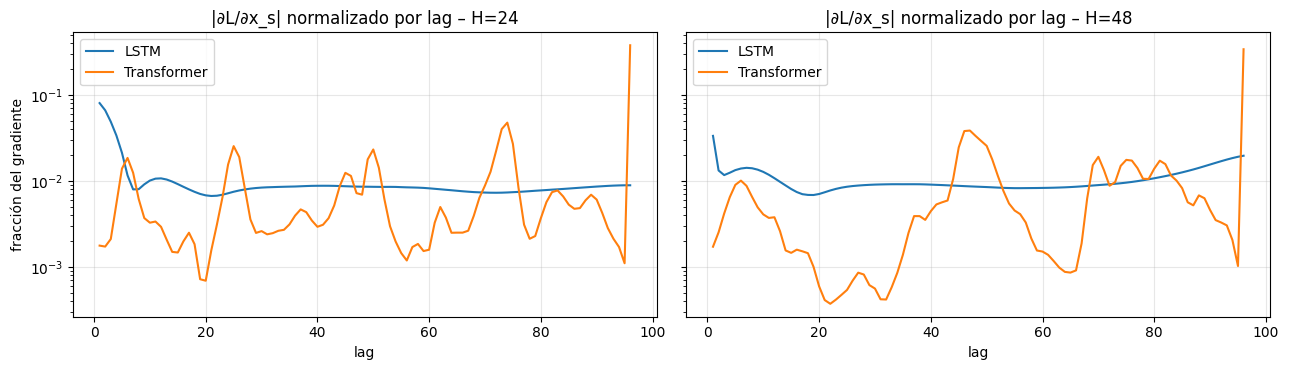

In [22]:
# Norma del gradiente que llega a cada paso de la entrada: ||∂L/∂x_s|| (flujo del gradiente por distancia)
def input_grad_by_lag(model, X, y, n=512):
    model.eval()
    X_rel, last = to_residual(X[:n])
    X_rel = X_rel.clone().to(device).requires_grad_(True)
    loss = F.mse_loss(model(X_rel), (y[:n] - last).to(device))
    loss.backward()
    g = X_rel.grad.abs().mean(0).cpu().numpy()
    return g / g.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)
for ax, H, (Xt, yt), (ml, mt) in zip(axes, (24, 48), ((X_vl_24, y_vl_24), (X_vl_48, y_vl_48)),
                                      ((lstm_24, trf_24), (lstm_48, trf_48))):
    gl, gt = input_grad_by_lag(ml, Xt, yt), input_grad_by_lag(mt, Xt, yt)
    ax.semilogy(lags, gl, label="LSTM"); ax.semilogy(lags, gt, label="Transformer")
    ax.set_title(f"|∂L/∂x_s| normalizado por lag – H={H}"); ax.set_xlabel("lag"); ax.grid(alpha=0.3); ax.legend()
    # Se excluye lag 96 (posición 0 = CLS), que en el Transformer recibe gradiente directo por la conexión residual
    near, far = (lags >= 1) & (lags <= 12), (lags >= 84) & (lags <= 95)
    fl = gl[(lags > 48) & (lags < 96)].sum() / gl[lags < 96].sum()
    ft = gt[(lags > 48) & (lags < 96)].sum() / gt[lags < 96].sum()
    print(f"H={H}: fracción del gradiente en lags 49-95 (sin CLS)  LSTM={fl:.3f}  Transformer={ft:.3f}"
          f" | gradiente medio lags 1-12 / lags 84-95  LSTM={gl[near].mean()/gl[far].mean():.2f}"
          f"  Transformer={gt[near].mean()/gt[far].mean():.2f}")
axes[0].set_ylabel("fracción del gradiente"); plt.tight_layout(); plt.show()

### Tabla comparativa (validación)

| Modelo | Horizonte | MAE | RMSE | Ratio vs naive |
|---|---|---|---|---|
| LSTM | 24h | 0.2098 | 0.2618 | 1.044 |
| LSTM | 48h | 0.2529 | 0.3150 | 0.965 |
| Transformer | 24h | 0.2245 | 0.2737 | 1.118 |
| Transformer | 48h | 0.2436 | 0.3148 | 0.930 |
| Naive | 24h | 0.2009 | 0.2689 | 1.000 |
| Naive | 48h | 0.2620 | 0.3380 | 1.000 |

(unidades normalizadas; multiplicar por σ = 8.51 para °C. En el conjunto de prueba el orden se mantiene en H=48: Transformer 0.958, LSTM 1.027.)

### a) ¿Por qué aumenta el error con el horizonte?

**Predicción iterativa (acumulación de error).** Si el modelo predijera un paso y se realimentara con su propia salida, $\hat x_{t+h}=f(\hat x_{t+h-1},\dots)$, el error en el paso $h$ sería
$$e_{t+h}\approx J_h\,e_{t+h-1}+\delta_{t+h}\;\;\Rightarrow\;\; e_{t+H}=\sum_{j=0}^{H-1}\Big(\prod_{i=1}^{j}J_{t+H-i+1}\Big)\delta_{t+H-j},$$
donde $\delta$ es el error de un paso y $J=\partial f/\partial x$. En el caso lineal AR(1) con coeficiente $\phi$:
$$\mathrm{Var}(e_{t+H})=\sigma_\delta^2\sum_{j=0}^{H-1}\phi^{2j}=\sigma_\delta^2\,\frac{1-\phi^{2H}}{1-\phi^2},$$
que crece monótonamente con $H$. Cada error se propaga a los pasos siguientes y se suma, por lo que pasar de 24 a 48 pasos suma 24 términos más.

**Direct multi-output (lo que implementamos: tanto el LSTM como el Transformer predicen $x_{t+H}$ en un solo paso).** No hay realimentación, pero el error crece igual porque:
1. **Aumenta la incertidumbre irreducible.** El valor futuro es $x_{t+H}=\mathbb E[x_{t+H}\mid\mathcal F_t]+\eta_{t+H}$, y $\mathrm{Var}(\eta_{t+H})$ acumula todas las perturbaciones entre $t$ y $t+H$ (cambios de carga, clima), aunque el modelo sea perfecto.
2. **Baja la información disponible.** La dependencia con el pasado decae con la distancia. Para el naive, $\mathbb E[(x_{t+H}-x_t)^2]=2\,\mathrm{Var}(x)\,(1-\rho(H))$. En validación $\rho(24)=0.858$ y $\rho(48)=0.776$, lo que da 0.076 y 0.120 (observado: 0.072 y 0.114). El error esperado crece ≈58% solo porque $\rho$ baja.
3. **La función a aprender es más difícil.** El mapeo ventana → $x_{t+H}$ es más ruidoso para $H$ grande, con menor razón señal/ruido. Por eso las curvas de pérdida de H=48 están siempre por encima (≈0.19 vs ≈0.13).

### b) ¿Por qué el Transformer supera al LSTM en H=48 pero no en H=24?

Es lo que se observa: en H=48 Transformer 0.930 vs LSTM 0.965; en H=24 Transformer 1.118 vs LSTM 1.044.

**Gradiente en el LSTM (BPTT).** La señal de error llega a la entrada $x_s$ recorriendo la cadena recurrente. Por el camino de la celda:
$$\frac{\partial\mathcal L}{\partial c_s}=\frac{\partial\mathcal L}{\partial c_L}\prod_{k=s+1}^{L}\frac{\partial c_k}{\partial c_{k-1}}\approx\frac{\partial\mathcal L}{\partial c_L}\prod_{k=s+1}^{L}\mathrm{diag}(f_k)\;(+\text{términos vía }h_{k-1}),$$
un producto de $L-s$ factores con $f_k\in(0,1)$. El gradiente decae de forma aproximadamente exponencial con la distancia ($\approx\bar f^{\,L-s}$), por lo que la información lejana se aprende con menos fuerza y el LSTM tiene un sesgo hacia lo reciente.

**Gradiente en el Transformer.** La salida sale del CLS: $z_0=\sum_s\alpha_{0s}\,v_s W_O$, con $v_s=W_V^\top h_s$. Entonces
$$\frac{\partial z_0}{\partial v_s}=\alpha_{0s}\,W_O^\top\quad(+\text{término por }\partial\alpha_{0s}/\partial h_s),$$
un camino de longitud 1 entre cualquier posición y la salida. La magnitud depende de cuánta atención recibe $s$, **no de su distancia** $L-s$.

**Explicación.**
- **En H=48 la información útil está lejos.** $|\mathrm{corr}(\tilde y,\tilde x_\ell)|$ es máxima en los lags 92–96 y 49–51. El Transformer lleva gradiente directo a esas posiciones y aprende a atenderlas (atención en 46–50 y 80–83). Medido: la fracción del gradiente $|\partial\mathcal L/\partial x_s|$ que llega a los lags 49–95 es **0.60 en el Transformer vs 0.51 en el LSTM**.
- **En H=24 lo lejano pesa menos y el sesgo del LSTM ayuda.** El LSTM concentra el gradiente en lo reciente: el gradiente medio en los lags 1–12 es **3.1 veces** el de los lags 84–95 (Transformer: 1.4). Ese sesgo de recencia es una buena regularización cuando el objetivo está a solo 24 h. El Transformer, sin ese sesgo y con el doble de parámetros, reparte la capacidad sobre toda la ventana y sobreajusta: tiene menor pérdida de train (0.1275 vs 0.1321) pero peor validación.
- **Matiz honesto:** el sesgo del forget gate en 1 y la entrada residual hacen que el LSTM no pierda el gradiente del todo (en H=48 su razón cerca/lejos es ≈0.95). Por eso la ventaja del Transformer en H=48 es moderada (ratio 0.930 vs 0.965) y no enorme.